In [1]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

mask = dat["total_cost_func"] < 10  # Filter bad samples

In [24]:
nmask = np.sum(mask)
nmask

241

Only 1/4 samples are good samples.

## U_i

### U_i vs V_off

Text(0, 0.5, 'U')

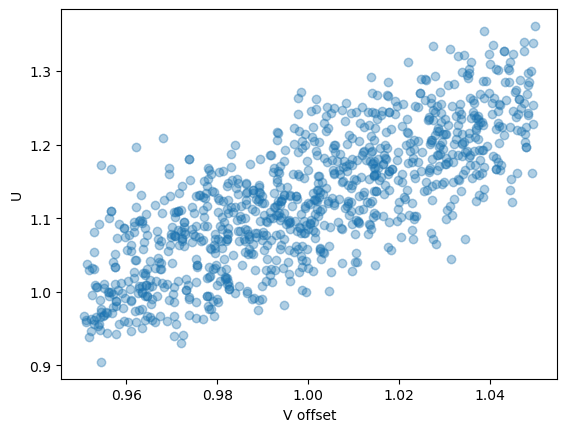

In [25]:
plt.scatter(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

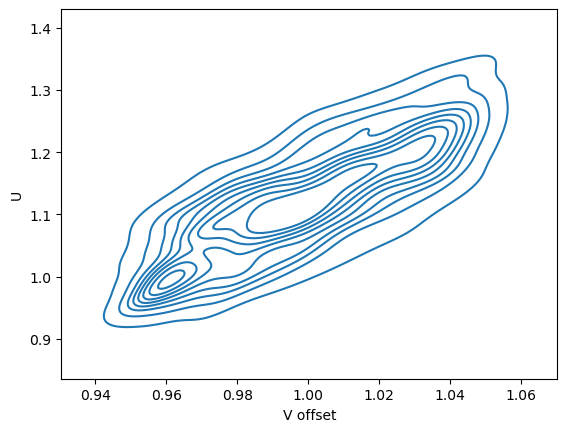

In [26]:
sns.kdeplot(x=dat["V_offset"][mask].flatten(), y=dat["U_i"][mask].flatten())
plt.xlabel("V offset")
plt.ylabel("U")

In [12]:
np.corrcoef(dat["V_offset"][mask].flatten(), dat["U_i"][mask].flatten())[0, 1]

0.7695943986846663

### U_i vs position

Site dependence of U, U_i vs i

NOTE: the below plot removes reflection-symmetric sites.

The site labeling is as below:
```
3 7 11 15
2 6 10 14
1 5 9 13
0 4 8 12
```

So if we take the left bottom quadrant the free sites are [0, 1, 4, 5].

Text(0, 0.5, 'U_i')

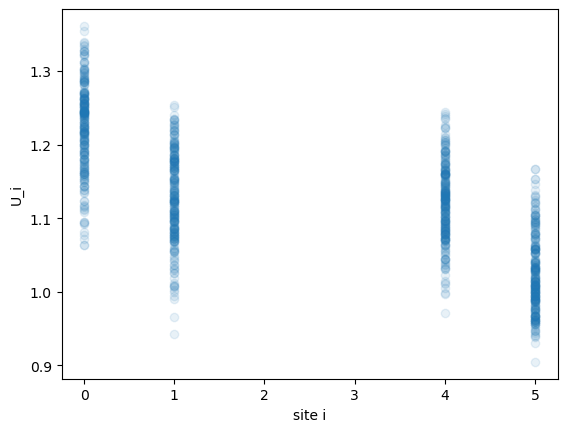

In [65]:
sidx = [0, 1, 4, 5]
plt.scatter(
    np.tile(sidx, nmask),
    dat["U_i"][mask][:, sidx].flatten(),
    alpha=0.1,
)
plt.xlabel("site i")
plt.ylabel("U_i")

A better description of this factor is the absolute location of trap centers:

Text(0, 0.5, 'V_i')

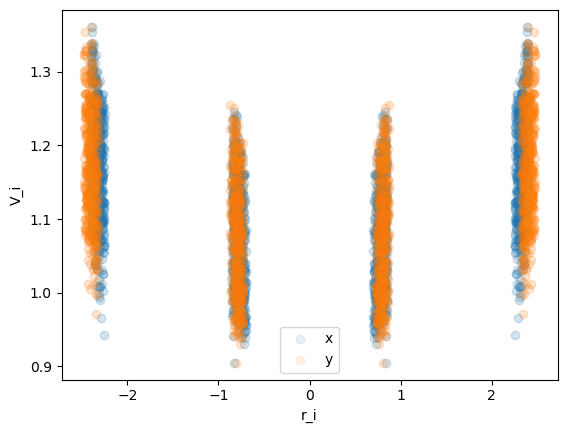

In [103]:
plt.scatter(
    dat["trap_centers"][mask, :, 0].flatten(),
    dat["U_i"][mask].flatten(),
    alpha=0.1,
    label="x",
)
plt.scatter(
    dat["trap_centers"][mask, :, 1].flatten(),
    dat["U_i"][mask].flatten(),
    alpha=0.1,
    label="y",
)
plt.legend()
plt.xlabel("r_i")
plt.ylabel("V_i")

## t_ij

### t_ij vs r_ij

Set rij as the distance between the ith and jth points in the dataset.

(-0.05, 0.7)

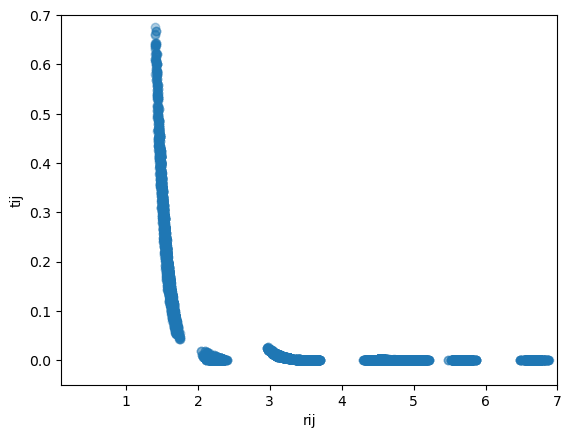

In [8]:
plt.scatter(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

In [11]:
np.corrcoef(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten())[0, 1]

-0.216242561882258

In [9]:
np.linalg.norm([1.55, 1.6])

2.2276669409945464

rij = 0 → j = i

rij ~ 2.4 → j = (ix + 1, iy + 1)

(-0.05, 0.5)

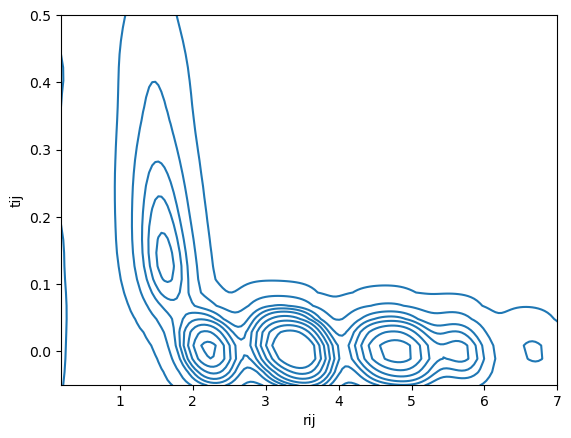

In [84]:
sns.kdeplot(x=dat["rij"][mask].flatten(), y=dat["t_ij"][mask].flatten())
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.2, 7)
plt.ylim(-0.05, 0.50)

Look at single cluster:

(-0.05, 0.7)

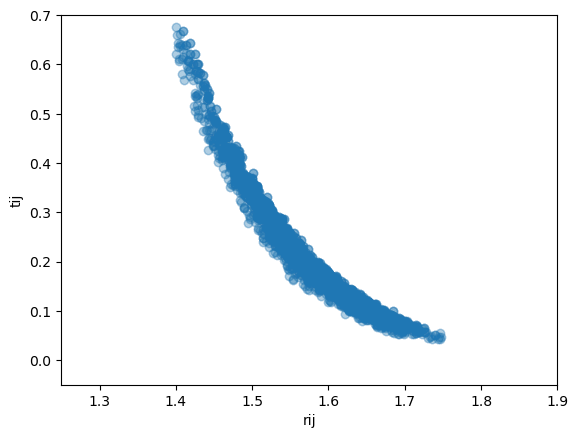

In [30]:
smallr = dat["rij"][mask].flatten() < 1.9

plt.scatter(
    x=dat["rij"][mask].flatten()[smallr],
    y=dat["t_ij"][mask].flatten()[smallr],
    alpha=0.1,
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(1.25, 1.9)
plt.ylim(-0.05, 0.7)

(0.05, 0.7)

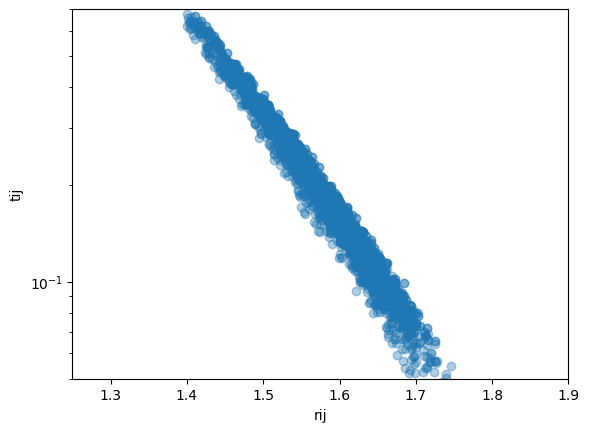

In [15]:
smallr = dat["rij"][mask].flatten() < 1.9

plt.scatter(
    x=dat["rij"][mask].flatten()[smallr],
    y=dat["t_ij"][mask].flatten()[smallr],
    alpha=0.1,
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")
plt.xlim(1.25, 1.9)
plt.ylim(0.05, 0.7)

In [24]:
np.corrcoef(
    dat["rij"][mask].flatten()[smallr], np.log(abs(dat["t_ij"][mask].flatten()[smallr]))
)[0, 1]

-0.4095558238299016

Exponential decay.

### t_ij vs r_i and r_j

Not only the relative distance, but the location in the lattice is also important.

(-0.05, 0.7)

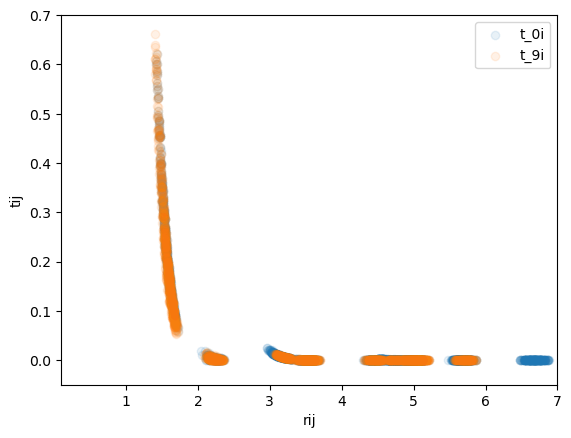

In [98]:
plt.scatter(
    dat["rij"][mask, 0, :].flatten(),
    dat["t_ij"][mask, 0, :].flatten(),
    alpha=0.1,
    label="t_0i",
)
plt.scatter(
    dat["rij"][mask, N // 2, 1:].flatten(),
    dat["t_ij"][mask, N // 2, 1:].flatten(),
    alpha=0.1,
    label="t_9i",
)
plt.legend()
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

(-0.05, 0.7)

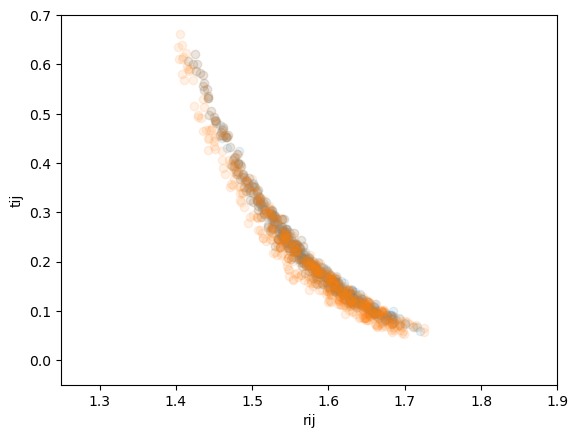

In [94]:
smallr = dat["rij"][mask, 0, :].flatten() < 1.9
plt.scatter(
    x=dat["rij"][mask, 0, :].flatten()[smallr],
    y=dat["t_ij"][mask, 0, :].flatten()[smallr],
    alpha=0.1,
)

smallr = dat["rij"][mask, N // 2, 1:].flatten() < 1.9
plt.scatter(
    x=dat["rij"][mask, N // 2, 1:].flatten()[smallr],
    y=dat["t_ij"][mask, N // 2, 1:].flatten()[smallr],
    alpha=0.1,
)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(1.25, 1.9)
plt.ylim(-0.05, 0.7)

Text(0, 0.5, 'U_i')

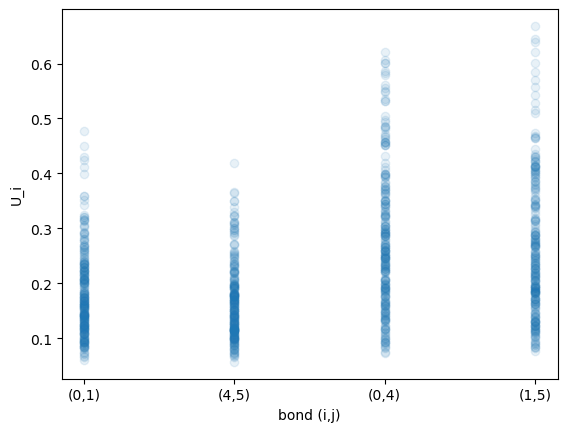

In [74]:
si = [0, 4, 0, 1]
sj = [1, 5, 4, 5]
plt.scatter(
    np.tile(np.arange(len(si)), nmask),
    dat["t_ij"][mask, :][:, si, sj].flatten(),
    alpha=0.1,
)
# These are your custom x labels
x_labels = ["(0,1)", "(4,5)", "(0,4)", "(1,5)"]
# Set the x-ticks to be your labels
plt.xticks(range(len(x_labels)), x_labels)
plt.xlabel("bond (i,j)")
plt.ylabel("U_i")

Text(0, 0.5, 'tij')

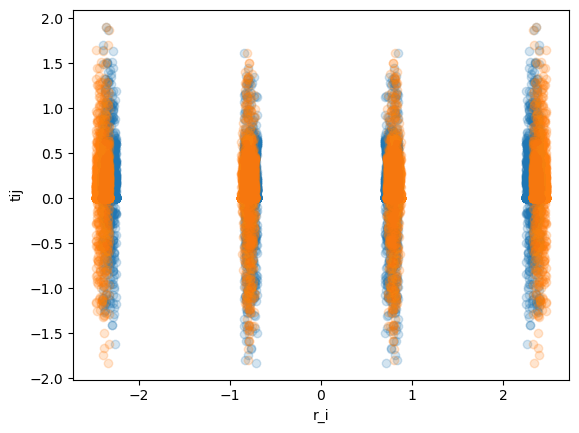

In [129]:
plt.scatter(
    np.tile(dat["trap_centers"][mask][:, :, [0]], (1, N)).flatten(),
    dat["t_ij"][mask].flatten(),
    alpha=0.1,
    label="x",
)
plt.scatter(
    np.tile(dat["trap_centers"][mask][:, :, [1]], (1, N)).flatten(),
    dat["t_ij"][mask].flatten(),
    alpha=0.1,
    label="y",
)
plt.xlabel("r_i")
plt.ylabel("tij")

### t_ij vs V_offset

Text(0, 0.5, 'tij')

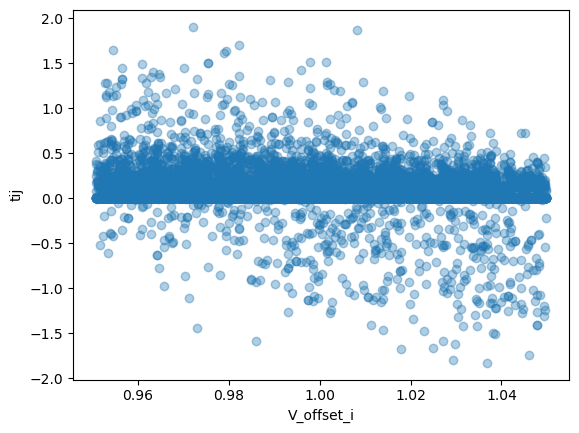

In [133]:
plt.scatter(
    np.tile(dat["V_offset"][mask][:, :, None], (1, N)).flatten(),
    dat["t_ij"][mask].flatten(),
    alpha=0.1,
)
plt.xlabel("V_offset_i")
plt.ylabel("tij")

Except the linear trend of V_i vs V_offset, no clear trend is observed for offdiag t_ij vs V_offset_i.

dV = V_offset_i - V_offset_j

Text(0, 0.5, 'tij')

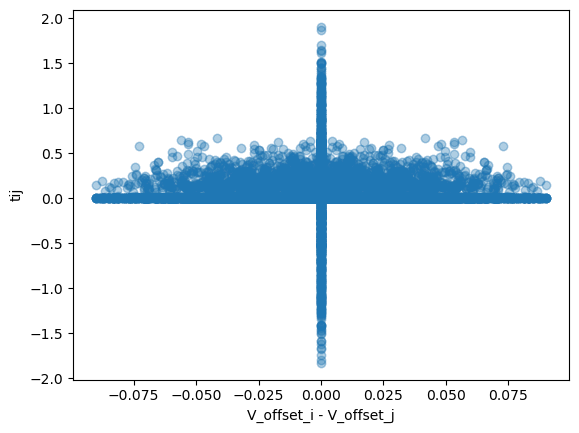

In [91]:
plt.scatter(dat["dV_ij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.xlabel("V_offset_i - V_offset_j")
plt.ylabel("tij")

### Angular dependence:

(-0.05, 0.7)

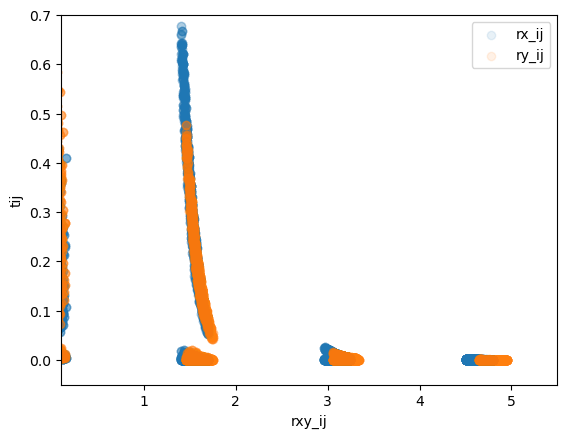

In [11]:
plt.scatter(dat["rx_ij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.scatter(dat["ry_ij"][mask].flatten(), dat["t_ij"][mask].flatten(), alpha=0.1)
plt.legend(["rx_ij", "ry_ij"])
plt.xlabel("rxy_ij")
plt.ylabel("tij")
plt.xlim(0.1, 5.5)
plt.ylim(-0.05, 0.7)

(-0.05, 0.7)

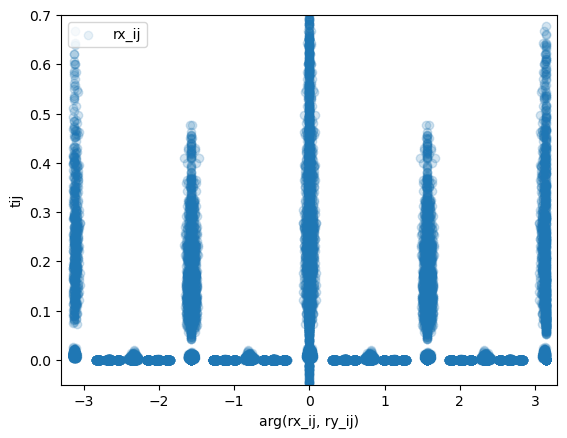

In [22]:
plt.scatter(
    np.arctan2(dat["ry_ij"][mask].flatten(), dat["rx_ij"][mask].flatten()),
    dat["t_ij"][mask].flatten(),
    alpha=0.1,
)
plt.legend(["rx_ij", "ry_ij"])
plt.xlabel("arg(rx_ij, ry_ij)")
plt.ylabel("tij")
plt.xlim(-1.05 * np.pi, 1.05 * np.pi)
plt.ylim(-0.05, 0.7)

t_ij has no clear angular dependence.

## V_i

### V_i vs V_offset

Text(0, 0.5, 'V')

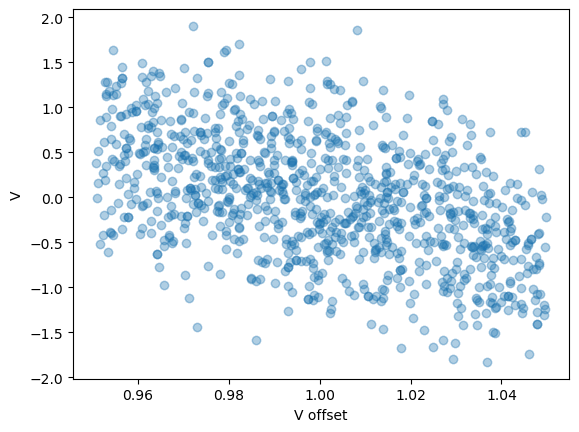

In [31]:
plt.scatter(
    dat["V_offset"][mask].flatten(),
    dat["t_ij"][mask].diagonal(axis1=1, axis2=2).flatten(),
    alpha=0.1,
)
plt.xlabel("V offset")
plt.ylabel("V")

In [32]:
np.corrcoef(
    dat["V_offset"][mask].flatten(),
    dat["t_ij"][mask].diagonal(axis1=1, axis2=2).flatten(),
)[0, 1]

-0.4764020888120715

(array([ 48., 204., 348., 624., 788., 736., 592., 332., 160.,  24.]),
 array([-1.82810614, -1.45489616, -1.08168619, -0.70847621, -0.33526623,
         0.03794374,  0.41115372,  0.7843637 ,  1.15757367,  1.53078365,
         1.90399362]),
 <BarContainer object of 10 artists>)

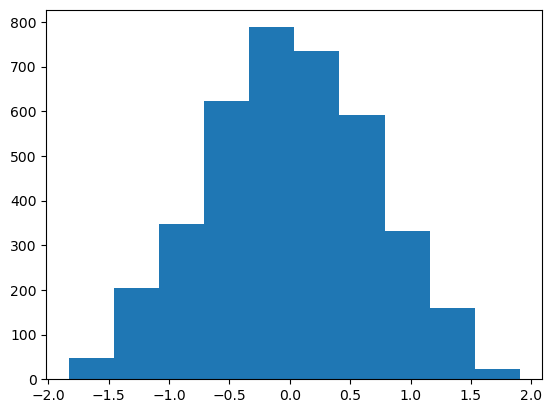

In [23]:
plt.hist(dat["t_ij"][mask].diagonal(axis1=1, axis2=2).flatten())

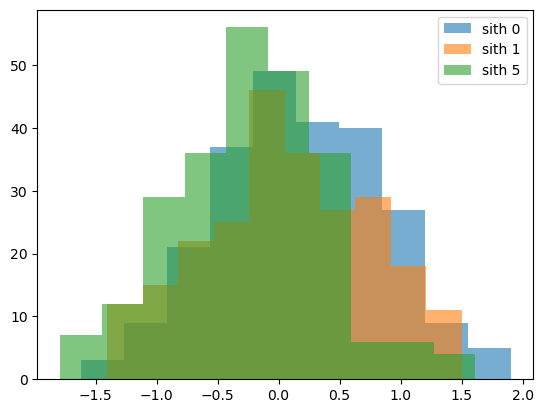

In [38]:
id = 0
plt.hist(
    dat["t_ij"].diagonal(axis1=1, axis2=2)[mask, id].flatten(),
    alpha=0.6,
    label=f"sith {id}",
)
id = 1
plt.hist(
    dat["t_ij"].diagonal(axis1=1, axis2=2)[mask, id].flatten(),
    alpha=0.6,
    label=f"sith {id}",
)
id = 5
plt.hist(
    dat["t_ij"].diagonal(axis1=1, axis2=2)[mask, id].flatten(),
    alpha=0.6,
    label=f"sith {id}",
)
plt.legend()

### V_i vs r_i

Text(0, 0.5, 'V_i')

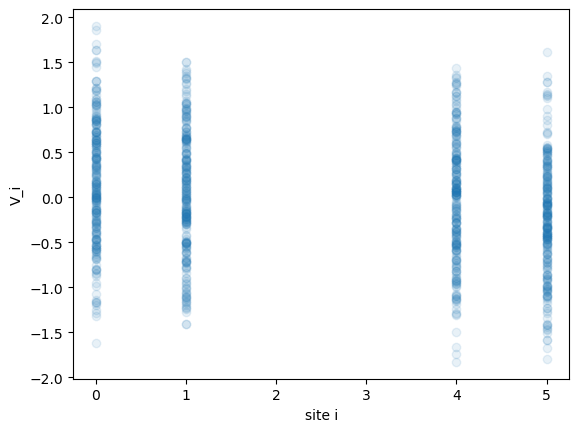

In [66]:
sidx = [0, 1, 4, 5]
plt.scatter(
    np.tile(sidx, nmask),
    dat["t_ij"][mask].diagonal(axis1=1, axis2=2)[:, sidx].flatten(),
    alpha=0.1,
)
plt.xlabel("site i")
plt.ylabel("V_i")

Trap center coordinate dependence:

Text(0, 0.5, 'V_i')

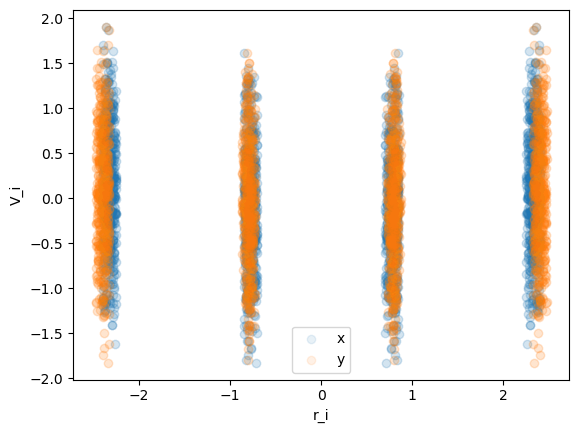

In [80]:
plt.scatter(
    dat["trap_centers"][mask, :, 0].flatten(),
    dat["t_ij"][mask].diagonal(axis1=1, axis2=2).flatten(),
    alpha=0.1,
    label="x",
)
plt.scatter(
    dat["trap_centers"][mask, :, 1].flatten(),
    dat["t_ij"][mask].diagonal(axis1=1, axis2=2).flatten(),
    alpha=0.1,
    label="y",
)
plt.legend()
plt.xlabel("r_i")
plt.ylabel("V_i")

## Correlation coefficients

In [42]:
np.corrcoef(dat["rij"][mask].flatten(), dat["t_ij"][mask].flatten())

array([[ 1.        , -0.21624256],
       [-0.21624256,  1.        ]])

In [41]:
# Stack the variables along one axis
data = np.vstack(
    (
        dat["V_offset"][mask].flatten(),
        dat["U_i"][mask].flatten(),
        dat["t_ij"][mask].diagonal(axis1=1, axis2=2).flatten(),
    )
)

# Compute the correlation matrix
correlation_matrix = np.corrcoef(data)
print(correlation_matrix)

[[ 1.          0.7695944  -0.47640209]
 [ 0.7695944   1.         -0.10732698]
 [-0.47640209 -0.10732698  1.        ]]


## Analyze anomalous data points

(array([923.,  48.,  16.,   2.,   3.,   5.,   2.,   0.,   0.,   1.]),
 array([5.59965378e-06, 1.92113284e-01, 3.84220969e-01, 5.76328653e-01,
        7.68436338e-01, 9.60544022e-01, 1.15265171e+00, 1.34475939e+00,
        1.53686708e+00, 1.72897476e+00, 1.92108244e+00]),
 <BarContainer object of 10 artists>)

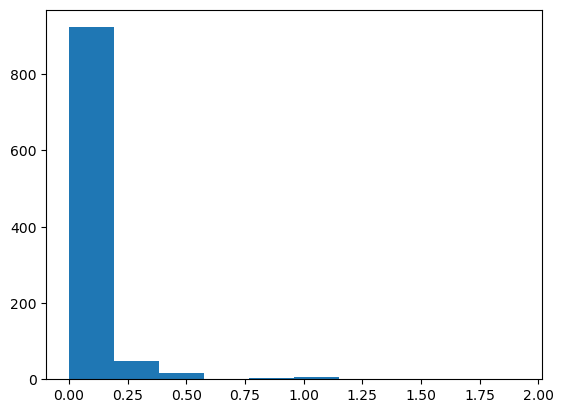

In [40]:
plt.hist(dat["t_ij"][:, 0, 5])

In [42]:
np.where(dat["t_ij"][:, 0, 5] > 1.5)

(array([545]),)

In [43]:
 dat["trap_centers"][545]

array([[-2.35134001, -2.35041483],
       [-2.30821494, -0.77222494],
       [-2.30821494,  0.77222494],
       [-2.35134001,  2.35041483],
       [-0.73808638, -2.47069622],
       [-0.75538482, -0.80011756],
       [-0.75538482,  0.80011756],
       [-0.73808638,  2.47069622],
       [ 0.73808638, -2.47069622],
       [ 0.75538482, -0.80011756],
       [ 0.75538482,  0.80011756],
       [ 0.73808638,  2.47069622],
       [ 2.35134001, -2.35041483],
       [ 2.30821494, -0.77222494],
       [ 2.30821494,  0.77222494],
       [ 2.35134001,  2.35041483]])

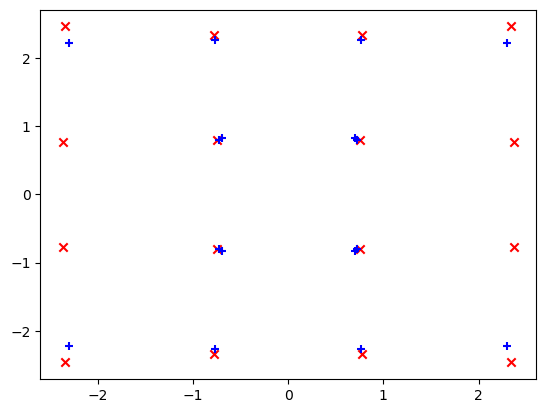

In [101]:
id = 0
plt.scatter(
    dat["trap_centers"][id, :, 0], dat["trap_centers"][id, :, 1], c="r", marker="x"
)
plt.scatter(dat["wf_centers"][id, :, 0], dat["wf_centers"][id, :, 1], c="b", marker="+")

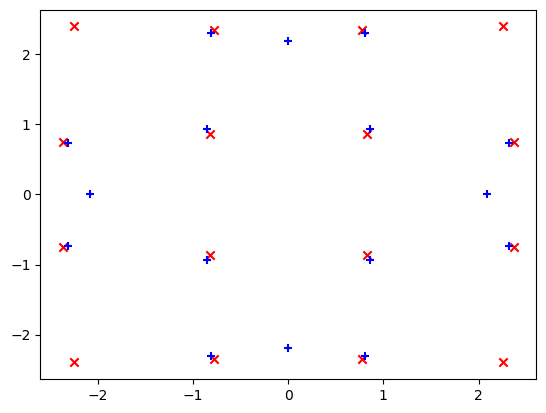

In [100]:
id = 14
plt.scatter(
    dat["trap_centers"][id, :, 0], dat["trap_centers"][id, :, 1], c="r", marker="x"
)
plt.scatter(dat["wf_centers"][id, :, 0], dat["wf_centers"][id, :, 1], c="b", marker="+")

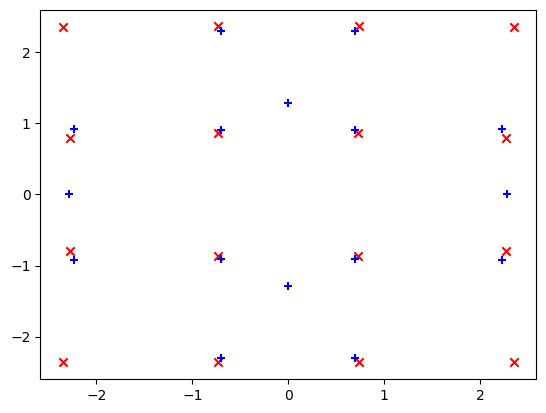

In [99]:
id = 545
plt.scatter(
    dat["trap_centers"][id, :, 0], dat["trap_centers"][id, :, 1], c="r", marker="x"
)
plt.scatter(dat["wf_centers"][id, :, 0], dat["wf_centers"][id, :, 1], c="b", marker="+")

Wannier functions are not centered on the trap. The anomalous data are from the failure of Tight-binding limit.

Conclusion: save `wf_centers` and `total_cost_func` to filter out bad samples.